In [80]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# # dx = 1 km; Np = 1M; Nt = 5 min
# data1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# parcel1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
# res='1km';t_res='5min'
# Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# dx = 1km; Np = 50M; Nz = 95
#Importing Model Data
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc') #***
parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc') #***
res='1km'; t_res='1min_95nz'; Np_str='50e6'

In [81]:
#LOADING IN H5 VARIABLES
file_path = dir + 'Variable_Calculation/' + f'theta_e_{res}_{t_res}.h5'
th_e_ds = xr.open_dataset(file_path, phony_dims='sort',engine='h5netcdf')  # or engine='netcdf4'
th_e_ds = th_e_ds.rename({
    'phony_dim_0': 'time',
    'phony_dim_1': 'zh',
    'phony_dim_2': 'yh',
    'phony_dim_3': 'xh'
})

file_path = dir + 'Variable_Calculation/' + '2D_Moisture_Convergence' + f'_{res}_{t_res}' + '.h5'
hmc_ds = xr.open_dataset(file_path, phony_dims='sort',engine='h5netcdf')  # or engine='netcdf4'
hmc_ds = hmc_ds.rename({
    'phony_dim_0': 'time',
    'phony_dim_1': 'zh',
    'phony_dim_2': 'yh',
    'phony_dim_3': 'xh'
})

In [82]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [83]:
#PROFILES AT SINGLE TIME

def CloudyPlot(t,var,var_name):
    
    var_z = np.mean(var,axis=(1,2))
    # var_z = np.mean(var,axis=(0,2,3))
    mask1 = (data['winterp'].isel(time=t) >= 0.5) & ((data['qc'].isel(time=t) + data['qi'].isel(time=t)) >= 1e-6)
    # print(np.any(mask1))
    # masked_profile1 = np.ma.masked_where(~mask1, var)
    masked_profile1 = np.where(~mask1, np.nan, var)
    var_cloudy= np.nanmean(masked_profile1, axis=(1, 2))
    # var_cloudy= np.nanmean(masked_profile1, axis=(0,2,3))
    print('done')
    
    #########################

    if var_name in ["qv","qc","HMC"]:
        var_z*=1000
        var_cloudy*=1000

    
    
    # New Subplots for Contour Plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    #First plot
    axes[0].plot(var_z,data['zh'])
    axes[0].axvline(0,color='black')
    axes[0].set_title('var(z) Horizontal Average for Eulerian Data Everywhere',fontsize=8)
    
    
    
    
    #Second plot
    axes[1].plot(var_cloudy,data['zh'])
    axes[1].axvline(0,color='black')
    axes[1].set_title(f'{var_name}(z) Horizontal Average for Eulerian Data (w ≥ 0.5) & (qc+qi ≥ 1e-6)',fontsize=8)
    
    
    apply_scientific_notation([axes[0],axes[1]])
    plt.suptitle(f'Horizontal Average of 2D {var_name} For Entire Domain vs Within Cloudy Updrafts (AT TIME {t})')
    # plt.tight_layout()

In [84]:
#PROFILES AT SINGLE TIME

def GeneralPlot(t,var,var_name):
    
    var_z = np.mean(var,axis=(1,2))
    # var_z = np.mean(var,axis=(0,2,3))
    mask1 = (data['winterp'].isel(time=t) >= 0.1) & ((data['qc'].isel(time=t) + data['qi'].isel(time=t)) < 1e-6)
    # print(np.any(mask1))
    # masked_profile1 = np.ma.masked_where(~mask1, var)
    masked_profile1 = np.where(~mask1, np.nan, var)
    var_cloudy= np.nanmean(masked_profile1, axis=(1, 2))
    # var_cloudy= np.nanmean(masked_profile1, axis=(0, 2, 3))
    print('done')
    
    #########################
    
    
    # New Subplots for Contour Plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    if var_name in ["qv","qc","HMC"]:
        var_z*=1000
        var_cloudy*=1000
    
    #First plot
    axes[0].plot(var_z,data['zh'])
    axes[0].axvline(0,color='black')
    axes[0].set_title('var(z) Horizontal Average for Eulerian Data Everywhere',fontsize=8)
    
    #Second plot
    axes[1].plot(var_cloudy,data['zh'])
    axes[1].axvline(0,color='black')
    axes[1].set_title(f'{var_name}(z) Horizontal Average for Eulerian Data (w ≥ 0.1) & (qc+qi < 1e-6)',fontsize=8)
    
    
    apply_scientific_notation([axes[0],axes[1]])
    plt.suptitle(f'Horizontal Average of 2D {var_name} For Entire Domain vs Within General Updrafts (AT TIME {t})')
    # plt.tight_layout()

done


/tmp/ipykernel_94963/526639422.py:11: RuntimeWarning: Mean of empty slice
  var_cloudy= np.nanmean(masked_profile1, axis=(1, 2))


done


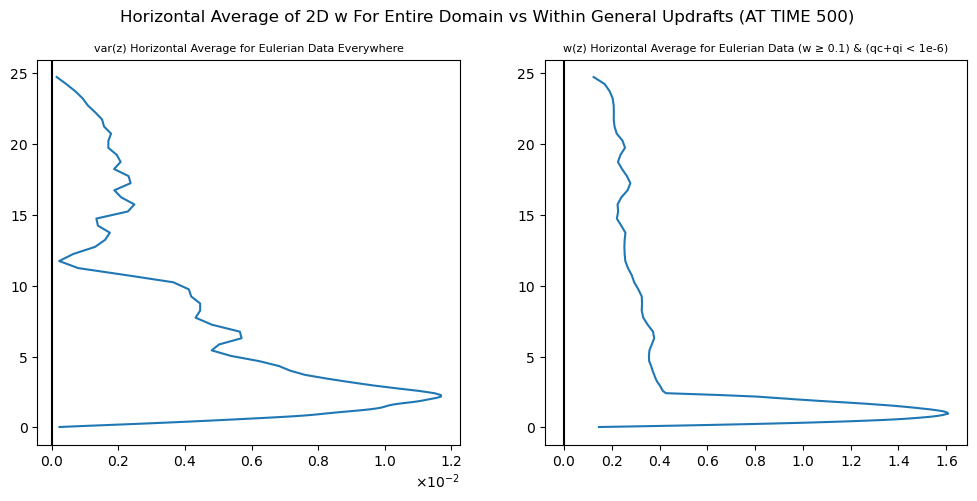

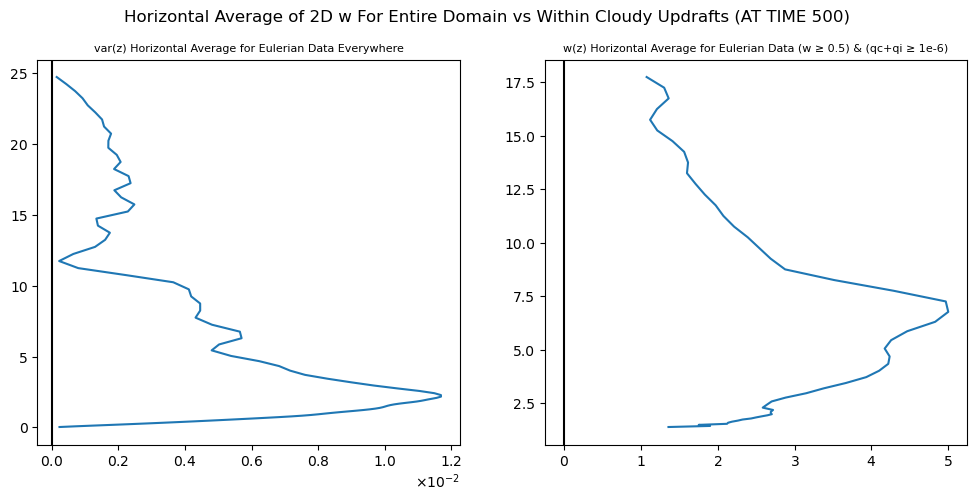

In [85]:
######################
#W

#READING BACK IN
t=500
w=data['winterp'].isel(time=t).data

GeneralPlot(t,w,"w")
CloudyPlot(t,w,"w")

In [86]:
def GeneralPlot(t, var):
    """
    Compute horizontal mean profile and cloudy updraft mean profile.
    
    Returns:
        var_z: Horizontal average over all x, y.
        var_cloudy: Horizontal average over regions with w ≥ 0.1 and qc+qi < 1e-6
    """
    var_z = np.mean(var, axis=(1, 2))
    
    w = data['winterp'].isel(time=t)
    qc = data['qc'].isel(time=t)
    qi = data['qi'].isel(time=t)
    
    mask1 = (w >= 0.1) & ((qc + qi) < 1e-6)
    masked_profile1 = np.where(~mask1, np.nan, var)
    var_cloudy = np.nanmean(masked_profile1, axis=(1, 2))
    return var_z, var_cloudy
def CloudyPlot(t, var):
    """
    Compute horizontal mean profile and cloudy updraft mean profile.
    
    Returns:
        var_z: Horizontal average over all x, y.
        var_cloudy: Horizontal average over regions with w ≥ 0.1 and qc+qi < 1e-6
    """
    var_z = np.mean(var, axis=(1, 2))
    
    w = data['winterp'].isel(time=t)
    qc = data['qc'].isel(time=t)
    qi = data['qi'].isel(time=t)
    
    mask1 = (w >= 0.5) & ((qc + qi) >= 1e-6)
    masked_profile1 = np.where(~mask1, np.nan, var)
    var_cloudy = np.nanmean(masked_profile1, axis=(1, 2))
    return var_z, var_cloudy
def MakePlot(var_z, var_cloudy, var_name, zh, updraft_type):
    """
    Plot the two profiles and return matplotlib axes.
    
    Returns:
        fig, axes: matplotlib figure and array of axes.
    """
    # Unit conversion
    if var_name in ["qv", "qc", "HMC"]:
        var_z *= 1000
        var_cloudy *= 1000
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # First plot: Full horizontal mean
    axes[0].plot(var_z, zh)
    axes[0].axvline(0, color='black')
    axes[0].set_title('var(z) Horizontal Average for Eulerian Data Everywhere', fontsize=8)
    
    # Second plot: Masked updraft region
    axes[1].plot(var_cloudy, zh)
    axes[1].axvline(0, color='black')
    if updraft_type=='general':
        axes[1].set_title(f'{var_name}(z) Horizontal Average for w ≥ 0.1 & (qc+qi < 1e-6)', fontsize=8)
    elif updraft_type=='cloudy':
        axes[1].set_title(f'{var_name}(z) Horizontal Average for w ≥ 0.5 & (qc+qi >= 1e-6)', fontsize=8)
    
    apply_scientific_notation(axes)
    plt.suptitle(f'Horizontal Average of 2D {var_name} For Entire Domain vs {updraft_type} Updrafts')
    
    return fig, axes


/tmp/ipykernel_94963/4159381964.py:35: RuntimeWarning: Mean of empty slice
  var_cloudy = np.nanmean(masked_profile1, axis=(1, 2))


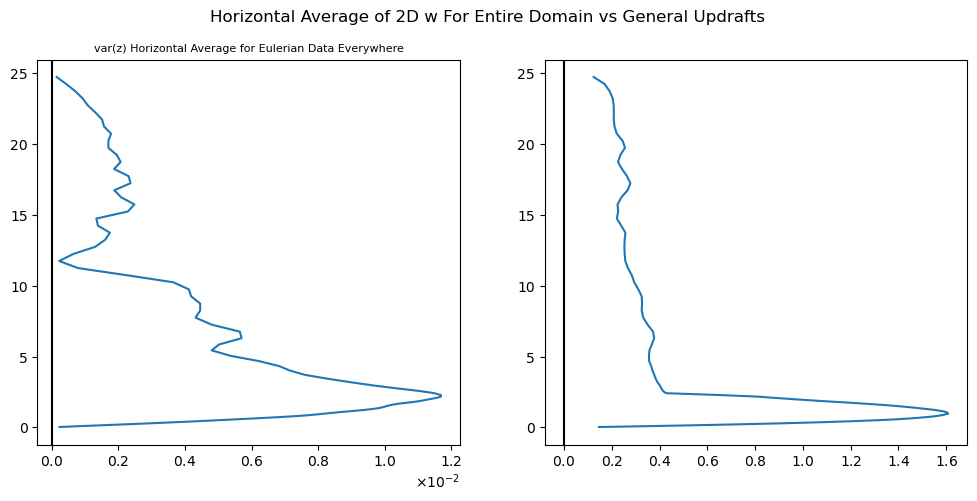

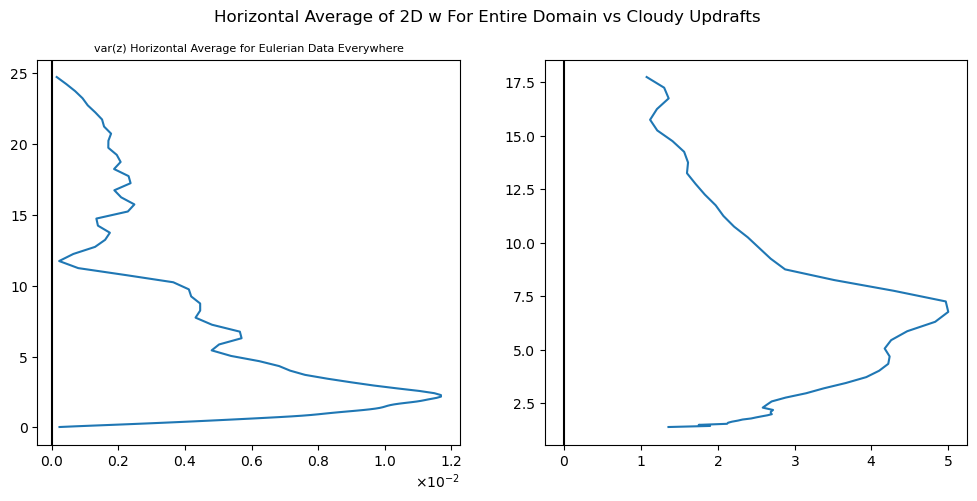

In [87]:
t = 500
w = data['winterp'].isel(time=t).data

# Compute profiles
w_z, w_general = GeneralPlot(t, w)
w_z, w_cloudy = CloudyPlot(t, w)

# Plot profiles
fig, axes = MakePlot(w_z, w_general, "w", data['zh'], 'General')
fig, axes = MakePlot(w_z, w_cloudy, "w", data['zh'], 'Cloudy')

In [88]:
# t = 500
# w = data['winterp'].isel(time=t).data

# # Compute profiles
# w_z, w_general = GeneralPlot(t, HMC)
# w_z, w_cloudy = CloudyPlot(t, HMC)

# # Plot profiles
# fig, axes = MakePlot(w_z, w_general, "HMC", data['zh'], 'General')
# fig, axes = MakePlot(w_z, w_cloudy, "HMC", data['zh'], 'Cloudy')

In [89]:
#######################################################

In [90]:
#MAKE A BUNCH OF PLOTS
#PROFILES AT SINGLE TIME
def MakePlot(t, var, var_name, ax):
    # mask1 = (data['winterp'].isel(time=t) >= 0.5) & ((data['qc'].isel(time=t) + data['qi'].isel(time=t)) >= 1e-6)
    # masked_profile1 = np.where(~mask1, np.nan, var)
    masked_profile1 = var
    var_cloudy = np.nanmean(masked_profile1, axis=(1,2))
    # var_cloudy = np.nanmean(masked_profile1, axis=(0, 2, 3))

    if var_name in ["qv", "qc", "HMC"]:
        var_cloudy *= 1000  # convert to g/kg or g/m^3

    ax.plot(var_cloudy, data['zh'])
    ax.axvline(0, color='black')
    ax.set_title(f'{var_name} (t={t})', fontsize=8)
    ax.set_xlabel(var_name)
    ax.set_ylabel('Height (m)')

    apply_scientific_notation([ax])
    return ax

current t 335
current t 340
current t 345
current t 350
current t 355
current t 360
current t 365


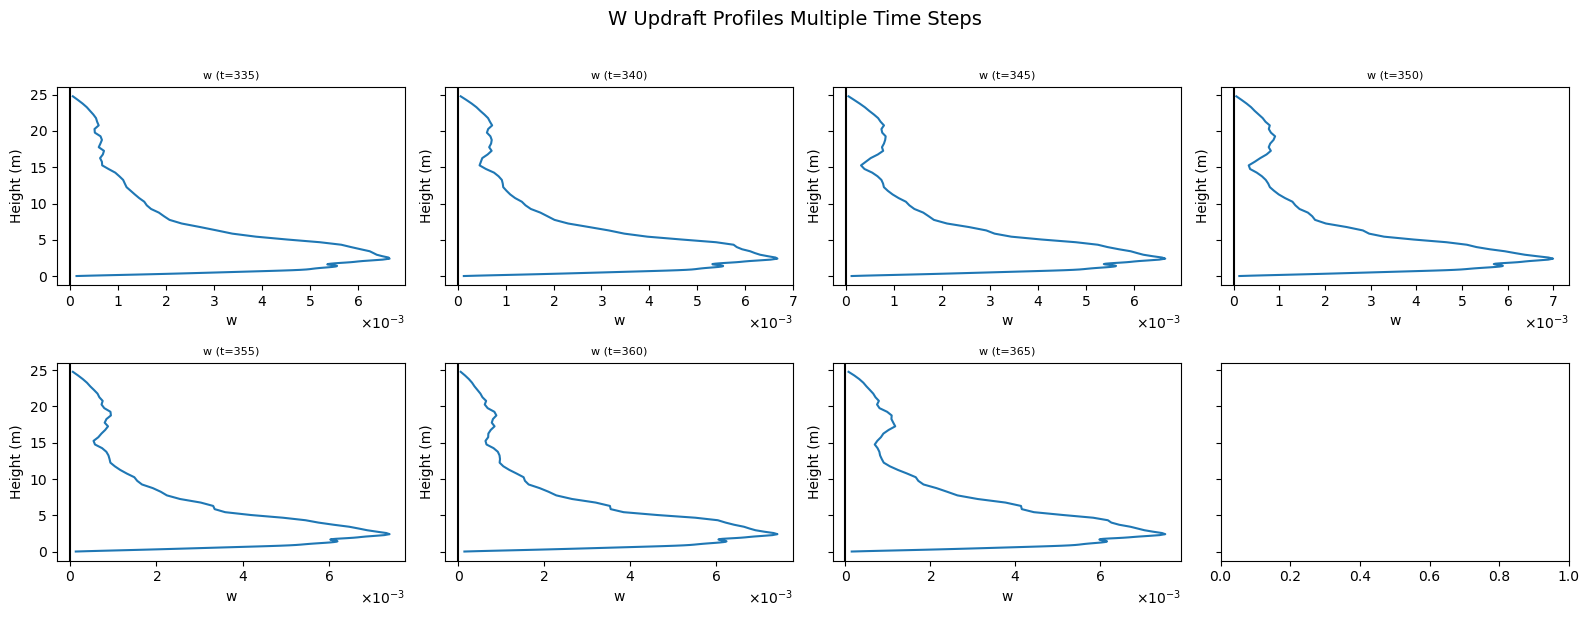

In [91]:
import warnings

######
# plot_dt=50
# t_indices = range(35, len(data['time']), plot_dt)
t_indices = range(335, 370, 5)
######

nplots = len(t_indices)
ncols = 4
nrows = int(np.ceil(nplots / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=True)
axs = axs.flatten()  # make 1D for easy indexing

for i, T in enumerate(t_indices):
    # t=slice(T,T+1)
    t=T
    print(f"current t {t}")
    var = data['winterp'].isel(time=t).data  # or whichever 4D variable you want to analyze
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        MakePlot(t, var, "w", axs[i])
        # MakePlot(t, var[t], "w", axs[i])

plt.suptitle("W Updraft Profiles Multiple Time Steps", fontsize=14, y=1.02)
plt.tight_layout()

current t 335
current t 340
current t 345
current t 350
current t 355
current t 360
current t 365


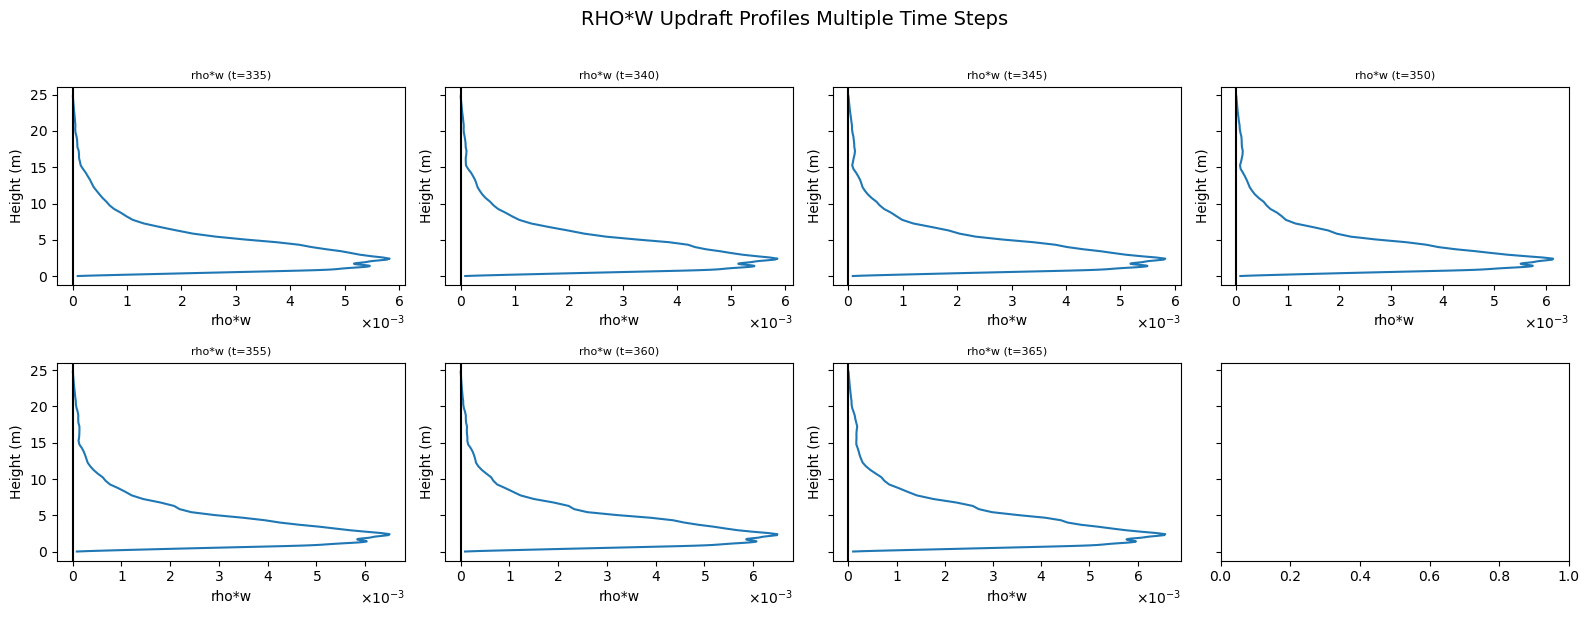

In [92]:
import warnings

######
# plot_dt=50
# t_indices = range(35, len(data['time']), plot_dt)
t_indices = range(335, 370, 5)
######

nplots = len(t_indices)
ncols = 4
nrows = int(np.ceil(nplots / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=True)
axs = axs.flatten()  # make 1D for easy indexing

for i, T in enumerate(t_indices):
    # t=slice(T,T+1)
    t=T
    print(f"current t {t}")
    var1 = data['winterp'].isel(time=t).data  
    var2 = data['rho'].isel(time=t).data  
    var=var1*var2
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        MakePlot(t, var, "rho*w", axs[i])
        # MakePlot(t, var[t], "w", axs[i])

plt.suptitle("RHO*W Updraft Profiles Multiple Time Steps", fontsize=14, y=1.02)
plt.tight_layout()

In [62]:
#MAKE A BUNCH OF PLOTS
#PROFILES AT SINGLE TIME
def CloudyPlot(t, var, var_name, ax):
    mask1 = (data['winterp'].isel(time=t) >= 0.5) & ((data['qc'].isel(time=t) + data['qi'].isel(time=t)) >= 1e-6)
    masked_profile1 = np.where(~mask1, np.nan, var)
    var_cloudy = np.nanmean(masked_profile1, axis=(1,2))
    # var_cloudy = np.nanmean(masked_profile1, axis=(0, 2, 3))

    if var_name in ["qv", "qc", "HMC"]:
        var_cloudy *= 1000  # convert to g/kg or g/m^3

    ax.plot(var_cloudy, data['zh'])
    ax.axvline(0, color='black')
    ax.set_title(f'{var_name} (t={t})', fontsize=8)
    ax.set_xlabel(var_name)
    ax.set_ylabel('Height (m)')

    apply_scientific_notation([ax])
    return ax

current t 335
current t 340
current t 345
current t 350
current t 355
current t 360
current t 365


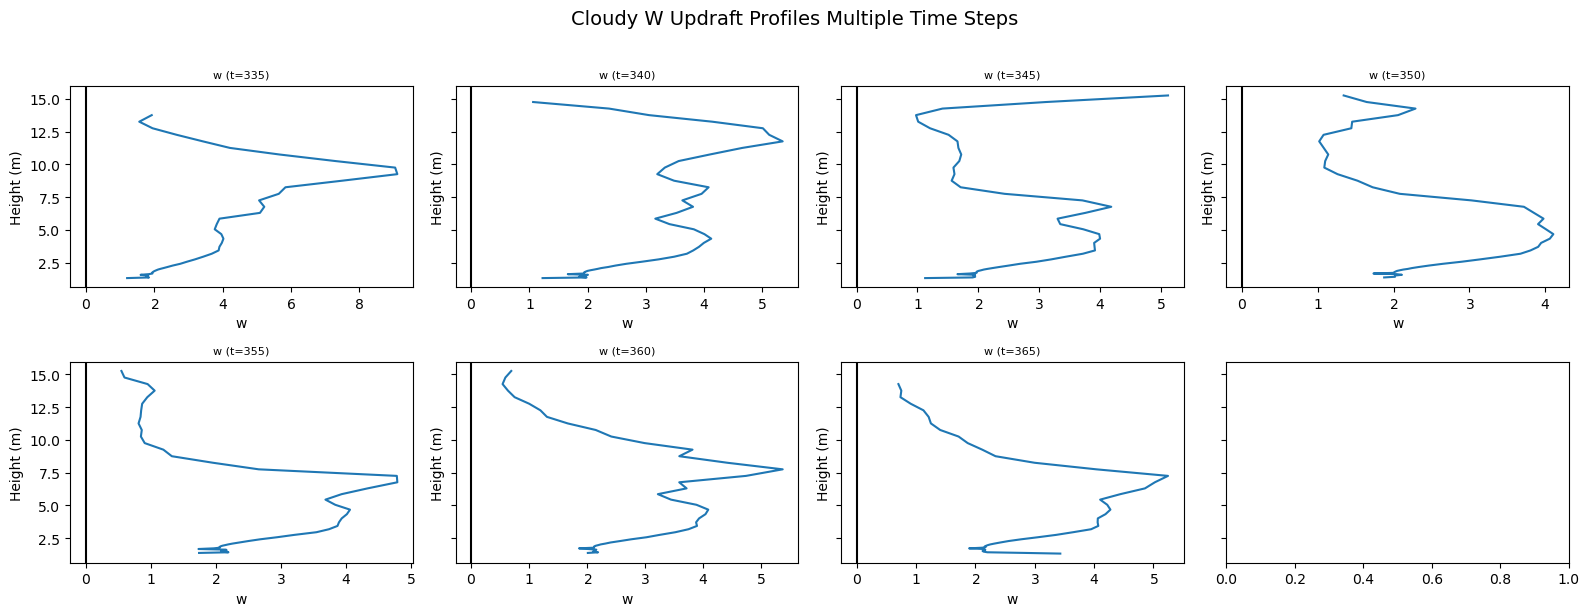

In [63]:
import warnings

######
# plot_dt=50
# t_indices = range(35, len(data['time']), plot_dt)
t_indices = range(335, 370, 5)
######

nplots = len(t_indices)
ncols = 4
nrows = int(np.ceil(nplots / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=True)
axs = axs.flatten()  # make 1D for easy indexing

for i, T in enumerate(t_indices):
    # t=slice(T,T+1)
    t=T
    print(f"current t {t}")
    var = data['winterp'].isel(time=t).data  # or whichever 4D variable you want to analyze
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        CloudyPlot(t, var, "w", axs[i])
        # CloudyPlot(t, var[t], "w", axs[i])

plt.suptitle("Cloudy W Updraft Profiles Multiple Time Steps", fontsize=14, y=1.02)
plt.tight_layout()

current t 335
current t 340
current t 345
current t 350
current t 355
current t 360
current t 365


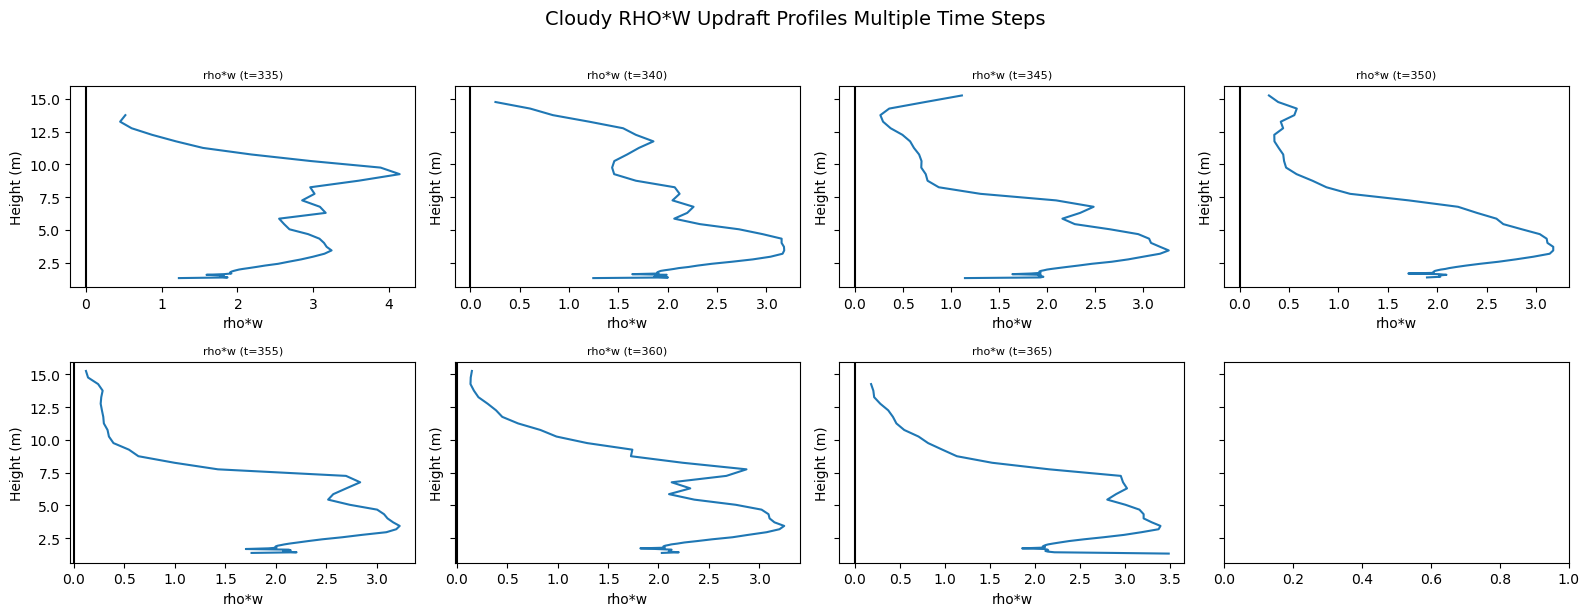

In [65]:
#NOW MULTIPLING BY RHO
import warnings

######
# plot_dt=50
# t_indices = range(35, len(data['time']), plot_dt)
t_indices = range(335, 370, 5)
######

nplots = len(t_indices)
ncols = 4
nrows = int(np.ceil(nplots / ncols))

fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=True)
axs = axs.flatten()  # make 1D for easy indexing

for i, T in enumerate(t_indices):
    # t=slice(T,T+1)
    t=T
    print(f"current t {t}")
    var1 = data['winterp'].isel(time=t).data  
    var2 = data['rho'].isel(time=t).data  
    var=var1*var2
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        CloudyPlot(t, var, "rho*w", axs[i])
        # CloudyPlot(t, var[t], "rho*w", axs[i])

plt.suptitle("Cloudy RHO*W Updraft Profiles Multiple Time Steps", fontsize=14, y=1.02)
plt.tight_layout()


In [77]:
# #HOW ABOUT VERTICAL MASS FLUX
# # ###############################################
# def GetA(t):
#     dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
#     out_file = dir2 + 'Variable_Calculation/' + f'Eulerian_Binary_Array_{res}_{t_res}.h5'
    
#     with h5py.File(out_file, 'r') as f:
#         A_g = f['A_g'][t]  # Loads the entire A_g array into memory
#         A_c = f['A_c'][t]  # Loads the entire A_c array into memory
#     return A_g,A_c

In [78]:
# #MAKE A BUNCH OF PLOTS
# #PROFILES AT SINGLE TIME
# def MakePlot(t, var, var_name, ax):
#     # mask1 = (data['winterp'].isel(time=t) >= 0.5) & ((data['qc'].isel(time=t) + data['qi'].isel(time=t)) >= 1e-6)
#     # masked_profile1 = np.where(~mask1, np.nan, var)
#     masked_profile1 = var
#     var_cloudy = np.nanmean(masked_profile1, axis=(1,2))
#     # var_cloudy = np.nanmean(masked_profile1, axis=(0, 2, 3))

#     if var_name in ["qv", "qc", "HMC"]:
#         var_cloudy *= 1000  # convert to g/kg or g/m^3

#     ax.plot(var_cloudy, data['zh'])
#     ax.axvline(0, color='black')
#     ax.set_title(f'{var_name} (t={t})', fontsize=8)
#     ax.set_xlabel(var_name)
#     ax.set_ylabel('Height (m)')

#     apply_scientific_notation([ax])
#     return ax

In [79]:
# #NOW MULTIPLING BY RHO
# import warnings

# ######
# # plot_dt=50
# # t_indices = range(35, len(data['time']), plot_dt)
# t_indices = range(335, 370, 5)
# ######

# nplots = len(t_indices)
# ncols = 4
# nrows = int(np.ceil(nplots / ncols))

# fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=True)
# axs = axs.flatten()  # make 1D for easy indexing

# for i, T in enumerate(t_indices):
#     # t=slice(T,T+1)
#     t=T
#     print(f"current t {t}")
#     var1 = data['winterp'].isel(time=t).data  
#     var2 = data['rho'].isel(time=t).data  
#     [A_g,A_c] = GetA(t); var3=A_c
#     var=var1*var2*var3
    
#     with warnings.catch_warnings():
#         warnings.simplefilter("ignore", category=RuntimeWarning)
#         MakePlot(t, var, "rho*w*A", axs[i])

# plt.suptitle("Cloudy RHO*W*A Updraft Profiles Multiple Time Steps", fontsize=14, y=1.02)
# plt.tight_layout()
